# Jaguar Re-ID — CNN Improved v2

**Architecture** : 4x(Conv2D + BatchNorm + MaxPool2D) → GlobalAveragePooling2D → Dropout → Dense(128) → Dense(31)  
**Improvement over Baseline** : +BatchNorm, architecture 4 blocs (32→64→128→256), Dropout(0.3), augmentation moderate, bug value_range corrigé  
**Diff vs v1** : Sweep patience remontée à 10/5 (compatible BatchNorm), bug augmentation corrigé (value_range)

## 1. Setup & data loading

In [2]:
import sys, os, glob
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

# GPU setup — LD_LIBRARY_PATH must be set before TF loads CUDA
nvidia_libs = glob.glob(os.path.join(sys.prefix, 'lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    os.environ['LD_LIBRARY_PATH'] = ':'.join(nvidia_libs) + ':' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ['CUDA_VISIBLE_DEVICES'] = '1'  # use GPU 1 (more free VRAM)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from sklearn.preprocessing import normalize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from src.config import *
from src.data import load_data, load_test_pairs, make_dataset

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(SUBMISSION_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU: {gpus}")
if not gpus:
    print("WARNING: No GPU detected, training will be slow on CPU!")
    print("Run this in terminal first: export LD_LIBRARY_PATH=$(python3 -c \"import glob; print(':'.join(glob.glob('env/lib/python*/site-packages/nvidia/*/lib')))\")")
    print("Then restart the Jupyter kernel.")

TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
MODEL_NAME   = 'cnn_improved_v2'
AUGMENTATION = 'moderate'
#   'none'     → raw images
#   'light'    → flip horizontal
#   'moderate' → flip + brightness + contrast
#   'heavy'    → flip + rotation + zoom + brightness + contrast

In [4]:
X_train, y_train = load_data('train')
X_val, y_val     = load_data('val')
test_pairs_df = load_test_pairs()

train_ds = make_dataset(X_train, y_train, training=True, augmentation=AUGMENTATION)
val_ds   = make_dataset(X_val, y_val)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Train batches: {len(train_ds)} | Val batches: {len(val_ds)}")

I0000 00:00:1775817179.437241 4128432 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 26501 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:86:00.0, compute capability: 8.6


Train: (1516, 224, 224, 3) | Val: (379, 224, 224, 3)
Train batches: 48 | Val batches: 12


## 2. Model architecture

In [5]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Conv2D(256, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name=MODEL_NAME)
    return model

model = build_model()
model.summary()

Model: "cnn_improved_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 31)             │         3,999 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 427,231 (1.63 MB)

 Trainable params: 426,271 (1.63 MB)

 Non-trainable params: 960 (3.75 KB)

## 3. Hyperparameter sweep

On teste plusieurs learning rates, on garde le meilleur.

In [6]:
def train_and_eval(lr, run_name):
    m = build_model()
    m.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    log_dir = os.path.join(LOG_DIR, MODEL_NAME, run_name)
    hist = m.fit(
        train_ds,
        validation_data=val_ds,
        epochs=100,
        callbacks=[
            callbacks.EarlyStopping(
                monitor='val_loss', patience=10, restore_best_weights=True
            ),
            callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0
            ),
            callbacks.TensorBoard(log_dir=log_dir),
        ],
        verbose=0
    )
    _, val_acc = m.evaluate(val_ds, verbose=0)
    best_epoch = np.argmin(hist.history['val_loss']) + 1
    print(f"  {run_name}: val_acc={val_acc:.4f} (best epoch={best_epoch})")
    return {'val_acc': val_acc, 'best_epoch': best_epoch, 'hist': hist.history}

In [7]:
lr_candidates = [1e-2, 1e-3, 1e-4]

results = {}
print(f"=== LR sweep ({MODEL_NAME}) ===")
for lr in lr_candidates:
    run_name = f'lr_{lr}'
    results[run_name] = train_and_eval(lr, run_name)

=== LR sweep (cnn_improved_v2) ===


I0000 00:00:1775817190.685680 4129058 service.cc:153] XLA service 0x7fc2c803f880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775817190.685712 4129058 service.cc:161]   StreamExecutor [0]: NVIDIA RTX A6000, Compute Capability 8.6 (Driver: 12.6.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775817190.913892 4129058 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775817191.604146 4129058 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775817191.724959 4129058 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4469__.73
I0000 00:00:1775817199.022902 4129058 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:0

  lr_0.01: val_acc=0.8575 (best epoch=62)


I0000 00:00:1775817495.021792 4129054 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_63305__.73
I0000 00:00:1775817504.570432 4129059 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_63305__.73


  lr_0.001: val_acc=0.9156 (best epoch=62)


I0000 00:00:1775817747.098915 4129060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122029__.73
I0000 00:00:1775817756.061560 4129057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122029__.73


  lr_0.0001: val_acc=0.8549 (best epoch=99)


In [8]:
rows = [{'Config': name, 'Val Accuracy': r['val_acc'], 'Best Epoch': r['best_epoch']}
        for name, r in results.items()]
results_df = pd.DataFrame(rows).sort_values('Val Accuracy', ascending=False).reset_index(drop=True)
display(results_df)

BEST_CONFIG = results_df.iloc[0]['Config']
BEST_LR = float(BEST_CONFIG.split('_')[1])
BEST_EPOCH = int(results_df.iloc[0]['Best Epoch'])
print(f"\nBest: {BEST_CONFIG} \u2192 val_acc={results_df.iloc[0]['Val Accuracy']:.4f}")

,Config,Val Accuracy,Best Epoch
0,lr_0.001,0.915567,62
1,lr_0.01,0.857520,62
2,lr_0.0001,0.854881,99



Best: lr_0.001 → val_acc=0.9156


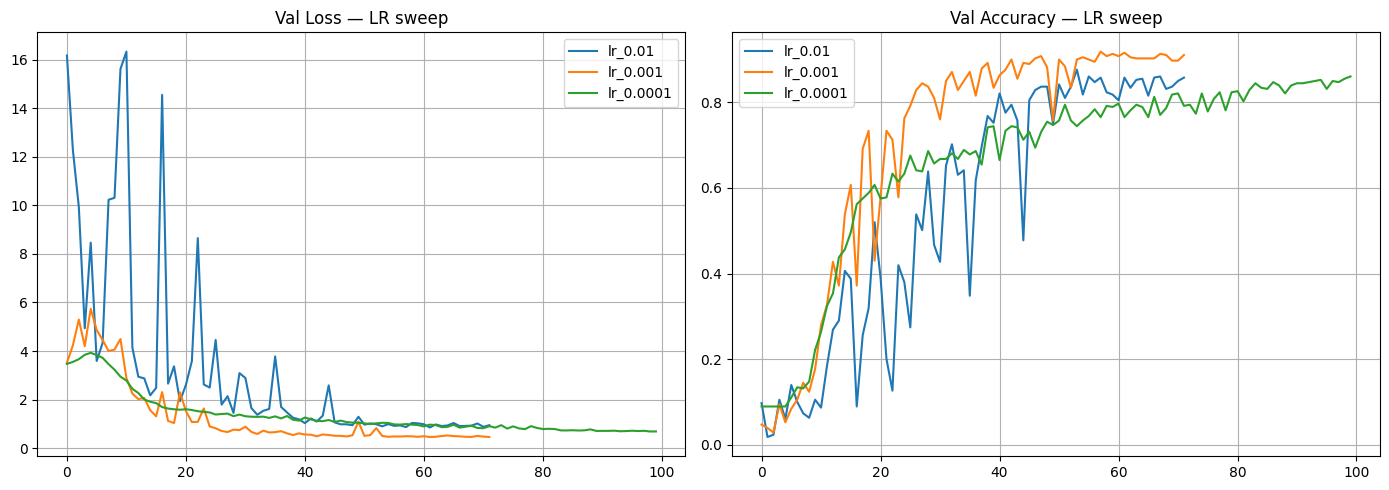

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, r in results.items():
    axes[0].plot(r['hist']['val_loss'],     label=name)
    axes[1].plot(r['hist']['val_accuracy'], label=name)
axes[0].set_title('Val Loss \u2014 LR sweep'); axes[0].legend(); axes[0].grid(True)
axes[1].set_title('Val Accuracy \u2014 LR sweep'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_lr_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation (best config)

In [10]:
model = build_model()
model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
log_dir = os.path.join(LOG_DIR, MODEL_NAME, f'best_{datetime.now().strftime("%Y%m%d-%H%M%S")}')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
        callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1),
    ],
    verbose=1
)

Epoch 1/100


I0000 00:00:1775818096.000031 4129060 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_203141__.73


47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1101 - loss: 3.1939

I0000 00:00:1775818105.133116 4129058 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_203141__.73


48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.1669 - loss: 2.9117 - val_accuracy: 0.0449 - val_loss: 3.8253 - learning_rate: 0.0010
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.2704 - loss: 2.4929 - val_accuracy: 0.0449 - val_loss: 4.7836 - learning_rate: 0.0010
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - accuracy: 0.3595 - loss: 2.1890 - val_accuracy: 0.0317 - val_loss: 5.7423 - learning_rate: 0.0010
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.4103 - loss: 1.9722 - val_accuracy: 0.0475 - val_loss: 6.5149 - learning_rate: 0.0010
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.4828 - loss: 1.8057 - val_accuracy: 0.0053 - val_loss: 6.3161 - learning_rate: 0.0010
Epoch 6/100
47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.4872 - loss: 1.7351
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.5218 - loss: 1.6421 - val_accuracy

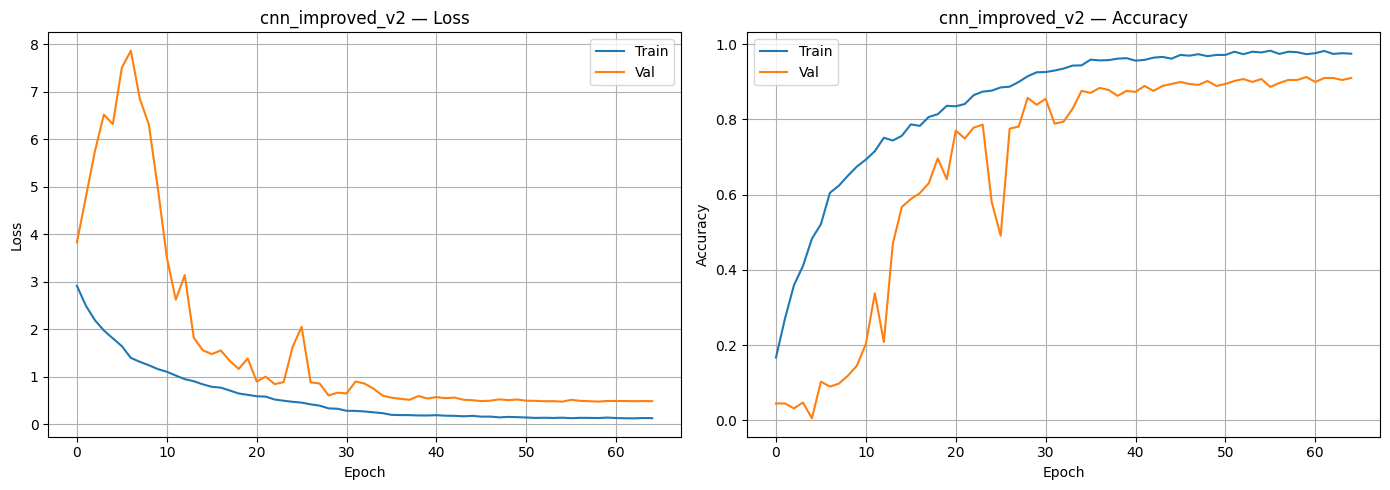

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{MODEL_NAME} \u2014 Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{MODEL_NAME} \u2014 Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_history.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss, val_acc     = model.evaluate(val_ds, verbose=0)

print(f"{MODEL_NAME} (best LR={BEST_LR}):")
print(f"  Train \u2014 Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
print(f"  Val   \u2014 Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

cnn_improved_v2 (best LR=0.001):
  Train — Loss: 0.0648, Acc: 0.9934
  Val   — Loss: 0.4732, Acc: 0.9077


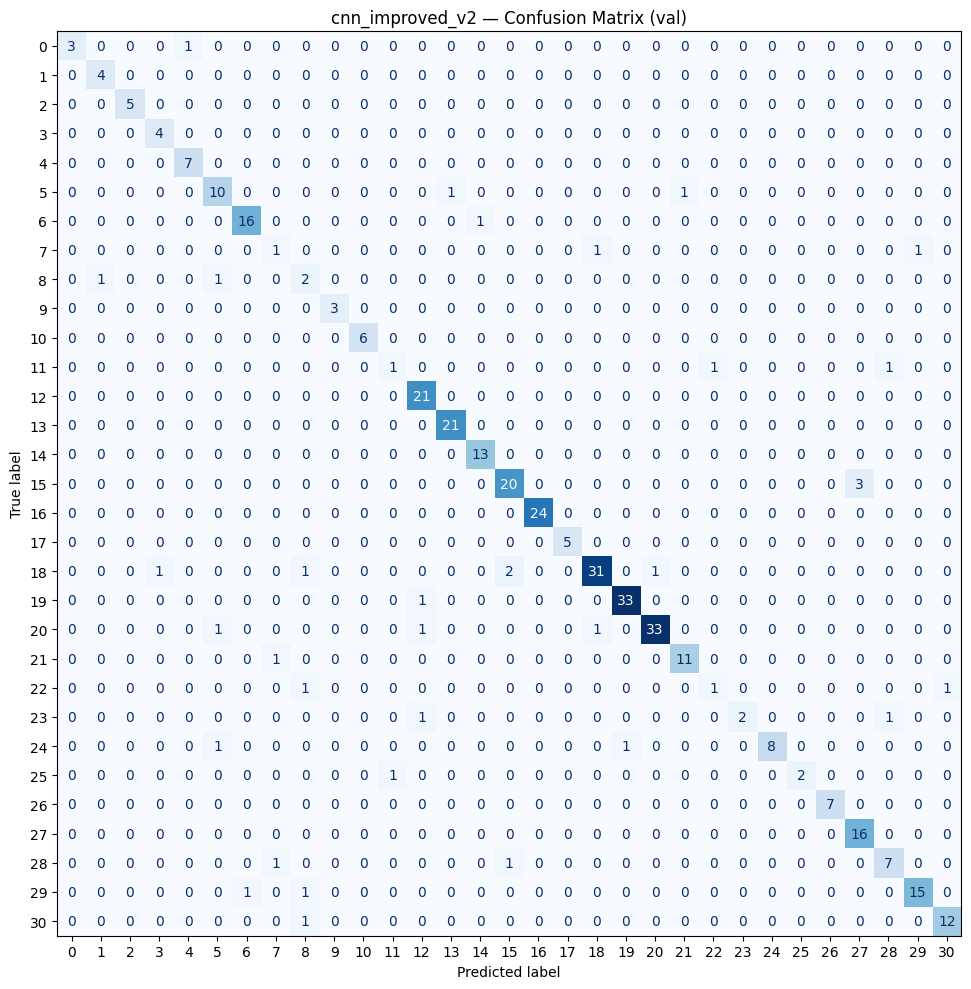

In [13]:
y_val_pred = model.predict(val_ds, verbose=0).argmax(axis=1)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'{MODEL_NAME} \u2014 Confusion Matrix (val)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Kaggle submission

In [14]:
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])
all_ds = make_dataset(X_all, y_all, training=True, augmentation=AUGMENTATION)

print(f"Retraining on full dataset ({len(X_all)} images) for {BEST_EPOCH} epochs")

final_model = build_model()
final_model.compile(
    optimizer=optimizers.Adam(learning_rate=BEST_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

final_log = os.path.join(LOG_DIR, MODEL_NAME, f'final_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
final_model.fit(
    all_ds, epochs=BEST_EPOCH,
    callbacks=[callbacks.TensorBoard(log_dir=final_log)],
    verbose=1
)
print(f"Final train acc: {final_model.evaluate(all_ds, verbose=0)[1]:.4f}")

Retraining on full dataset (1895 images) for 62 epochs
Epoch 1/62


I0000 00:00:1775818368.146240 4129057 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_505112__.73


59/60 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.1190 - loss: 3.1566

I0000 00:00:1775818377.683095 4129059 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_505112__.73


60/60 ━━━━━━━━━━━━━━━━━━━━ 32s 369ms/step - accuracy: 0.1789 - loss: 2.8860
Epoch 2/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3082 - loss: 2.4062
Epoch 3/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.3879 - loss: 2.1253
Epoch 4/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.4570 - loss: 1.9354
Epoch 5/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.5161 - loss: 1.7291
Epoch 6/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5694 - loss: 1.5296
Epoch 7/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6058 - loss: 1.4370
Epoch 8/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6253 - loss: 1.3128
Epoch 9/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.6839 - loss: 1.1576
Epoch 10/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6902 - loss: 1.0829
Epoch 11/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.7235 - loss: 1.0000
Epoch 12/62
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7467 -

In [15]:
X_test, test_filenames = load_data('test')

inp = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = inp
for layer in final_model.layers[:-1]:
    x = layer(x)
embedding_model = keras.Model(inputs=inp, outputs=x, name=f'{MODEL_NAME}_embedding')

test_embeddings = embedding_model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
test_embeddings_norm = normalize(test_embeddings, axis=1)
print(f"Embedding shape: {test_embeddings_norm.shape}")

del X_test  # free memory

fname_to_idx = {fname: i for i, fname in enumerate(test_filenames)}
query_idx   = test_pairs_df['query_image'].map(fname_to_idx).values
gallery_idx = test_pairs_df['gallery_image'].map(fname_to_idx).values

# Chunked to avoid OOM on high-dim embeddings
CHUNK = 1000
similarities = np.empty(len(query_idx), dtype=np.float32)
for start in range(0, len(query_idx), CHUNK):
    sl = slice(start, start + CHUNK)
    q = test_embeddings_norm[query_idx[sl]]
    g = test_embeddings_norm[gallery_idx[sl]]
    similarities[sl] = np.clip((q * g).sum(axis=1), 0, 1)

submission = pd.DataFrame({'row_id': test_pairs_df['row_id'], 'similarity': similarities})
submission_path = os.path.join(SUBMISSION_DIR, f'submission_{MODEL_NAME}.csv')
submission.to_csv(submission_path, index=False)
print(f"Saved: {submission_path}")
display(submission.head())

12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step
Embedding shape: (371, 128)
Saved: /HomeSweetHome/FHuang5/Developer/kaggle_jaguar_classification/submissions/submission_cnn_improved_v2.csv


,row_id,similarity
0,0,0.957723
1,1,0.713712
2,2,0.461529
3,3,0.510582
4,4,0.657327


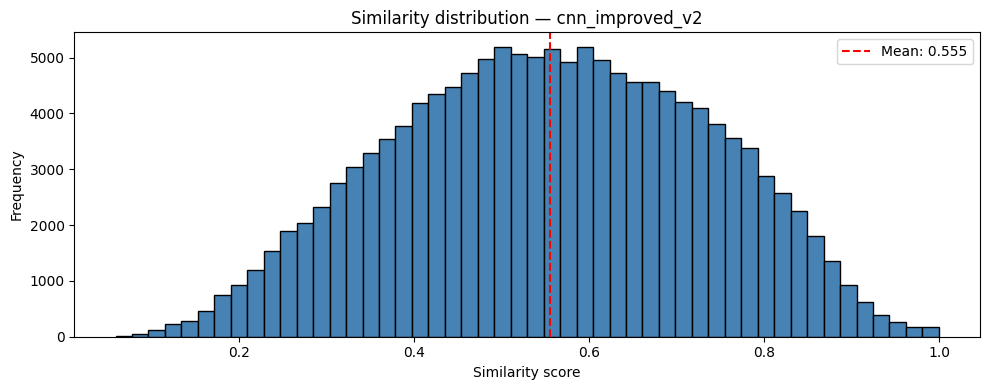

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(similarities, bins=50, color='steelblue', edgecolor='black')
ax.axvline(similarities.mean(), color='red', linestyle='--', label=f'Mean: {similarities.mean():.3f}')
ax.set_xlabel('Similarity score'); ax.set_ylabel('Frequency')
ax.set_title(f'Similarity distribution \u2014 {MODEL_NAME}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{MODEL_NAME}_similarity.png'), dpi=150, bbox_inches='tight')
plt.show()

## 6. Observations & Verdict

### Résultats

| Métrique | Train | Val |
|----------|-------|-----|
| Accuracy | 0.9934 | 0.9077 |
| Loss     | 0.0648 | 0.4732 |
| Overfitting ? | — | Modéré (gap ~8.6 pts) |
| Kaggle Score (public) | — | 0.361 |
| Kaggle Score (private) | — | 0.343 |

### Comparaison vs v1

| Métrique | v1 | v2 |
|----------|-----|-----|
| Val Acc (Section 4) | 0.8628 | 0.9077 |
| Kaggle (public) | 0.171 | 0.361 |
| Sweep cohérent ? | Non (11%, 4.7%, 8.9%) | Oui (85.5%, 91.6%, 85.5%) |
| Best epoch (sweep) | 5 (aberrant) | 62 |

Le Kaggle v1 (0.171) est trompeur : le sweep buggé sélectionnait best_epoch=5, donc le retrain final produisait un modèle sous-entraîné. La val_acc de la Section 4 (patience=10) montrait déjà 86.28%, preuve que l'architecture fonctionnait — c'est le pipeline sweep→retrain qui était cassé.

### Analyse des hyperparamètres

#### 1. Learning Rate — hyperparamètre le plus influent

| LR | Val Acc | Best Epoch | Comportement |
|----|---------|------------|-------------|
| 1e-2 | 0.8575 | 62 | Convergence rapide mais instable — le LR élevé fait osciller autour du minimum |
| **1e-3** | **0.9156** | **62** | **Meilleur équilibre exploration/convergence** |
| 1e-4 | 0.8549 | 99 | Trop lent — n'a pas convergé en 100 epochs, le modèle n'explore pas assez |

**Impact** : ±6 points de val_acc entre le meilleur et le pire LR. C'est l'hyperparamètre qui fait la plus grande différence sur la performance finale. Un LR trop haut empêche le modèle de se stabiliser dans un bon minimum, un LR trop bas le piège dans un minimum local médiocre.

#### 2. Patience (EarlyStopping=10, ReduceLR=5) — correction critique vs v1

Dans v1, la patience était à 5/3 (réduite pour accélérer le sweep sur CPU). C'était trop court pour BatchNorm : les running statistics n'avaient pas le temps de se stabiliser, ce qui produisait des val_acc aberrantes dans le sweep. Le sweep sélectionnait alors un best_epoch=5, et le retrain final produisait un modèle sous-entraîné → Kaggle 0.171.

**Impact** : En remontant à 10/5, le sweep donne des résultats cohérents (85-92% pour les 3 LR). Le ReduceLROnPlateau a effectué 7 réductions (de 1e-3 → 8e-6), permettant un affinage progressif. Le modèle converge à l'epoch 55 (val_loss=0.4732) et l'EarlyStopping arrête correctement à l'epoch 65.

#### 3. Data Augmentation (moderate) — bug corrigé vs v1

Dans v1, `RandomBrightness(0.2)` utilisait le `value_range` par défaut [0, 255] alors que nos images sont normalisées en [0, 1]. Cela corrompait les images augmentées → effondrement du modèle lors du premier run v1 (acc ~9.5%, toutes les similarités = 1.0). Corrigé en ajoutant `value_range=(0.0, 1.0)` dans `src/data.py`.

**Impact** : Sans ce fix, l'augmentation détruisait les images. Avec le fix, elle contribue à la régularisation en montrant des variations réalistes (flip, brightness ±0.2, contrast ±0.2). Couplée au Dropout, elle maintient le gap d'overfitting à ~8.6 pts, raisonnable pour 1516 images.

#### 4. Dropout (0.3)

Le Dropout désactive aléatoirement 30% des neurones entre le GlobalAveragePooling et le Dense(128) pendant le training. Cela force le réseau à ne pas dépendre de neurones spécifiques → meilleure généralisation.

**Impact** : Train acc=99.34% vs Val acc=90.77% → gap de 8.6 points. Le Dropout régularise mais ne suffit pas à combler entièrement le gap. Un Dropout plus élevé (0.4-0.5) pourrait réduire l'overfitting.

#### 5. BatchNormalization

Même architecture que v1 (4 blocs Conv2D + BN + MaxPool2D). La BN normalise les activations entre chaque couche (moyenne=0, variance=1), stabilise le gradient et permet un LR plus élevé. Mais elle nécessite une patience suffisante pour que ses running statistics convergent — c'est exactement le problème qu'on avait en v1.

**Impact** : Inchangé vs v1 (même architecture). L'impact se mesure vs le CNN baseline (sans BN) : +22 pts de val_acc.

### Verdict

- [x] Improvable → Instructions pour v3
- [ ] Not Improvable → Plafond atteint
- [ ] Dead-end → On abandonne cette architecture

**Justification** : Val_acc=90.77% et Kaggle=0.361 sont de bons résultats pour un CNN from scratch. L'overfitting modéré (gap 8.6 pts) indique qu'on peut encore améliorer la régularisation.

**Instructions pour v3** :
- Augmenter la régularisation : passer à `augmentation='heavy'` (ajout rotation + zoom)
- Tester Dropout(0.4 ou 0.5) pour réduire le gap d'overfitting
- Éventuellement ajouter un 5e bloc conv ou augmenter les filtres pour plus de capacité

### Interprétation

_Ce notebook corrige les deux bugs de v1 : le value_range de RandomBrightness et la patience trop basse pour BatchNorm. Le sweep fonctionne enfin correctement et le pipeline sweep→retrain produit un modèle cohérent. Le passage de Kaggle 0.171 (v1, buggé) à 0.361 (v2) n'est pas une amélioration de l'architecture mais la preuve que v1 n'a jamais pu montrer son vrai potentiel. Pour v3, la marge de progression est sur la régularisation (heavy augmentation, Dropout plus fort)._